**Goal : To discover deterministic SIR laws from noisy, stochastic Gillespie simulations.**

Implementation of the Gillespie Direct Method to simulate stochastic epidemic trajectories. To handle the computational load of generating thousands of trajectories for Neural ODE training, we use Numba's Just-In-Time (JIT) compilation. This allows our simulation to run at near-C speeds while maintaining Pythonic readability.
Ground Truth Parameters: β=0.5 (Infection Rate), γ=0.1 (Recovery Rate).
Task: Transform discrete, non-uniformly spaced event data into normalized population fractions [S,I,R] on a fixed time grid.

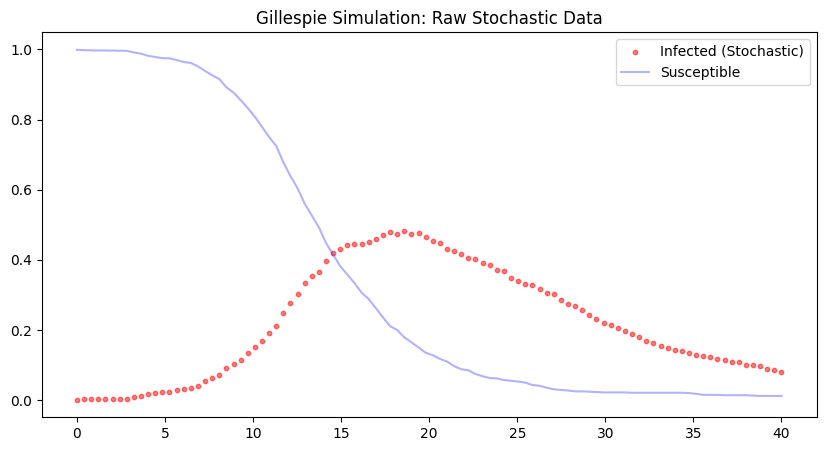

In [1]:
import numpy as np
from numba import njit
from typing import Tuple
import matplotlib.pyplot as plt

@njit(fastmath=True)
def gillespie_step(S, I, R, beta, gamma, N):
    rate_infection = beta * S * I / N
    rate_recovery = gamma * I
    rate_total = rate_infection + rate_recovery

    if rate_total <= 1e-12:
        return 1e8, S, I, R 

    dt = -np.log(np.random.random()) / rate_total
    
    if np.random.random() * rate_total < rate_infection:
        S -= 1.0
        I += 1.0
    else:
        I -= 1.0
        R += 1.0
    return dt, S, I, R

@njit
def simulate_epidemic(beta, gamma, N=1000.0, I0=1.0, max_time=50.0):
    S, I, R = N - I0, I0, 0.0
    t = 0.0
    max_steps = int(2.5 * N) 
    history = np.zeros((max_steps, 4), dtype=np.float32)
    step = 0
    history[step] = [t, S, I, R]
    
    while t < max_time and I > 0 and step < max_steps - 1:
        dt, S, I, R = gillespie_step(S, I, R, beta, gamma, N)
        t += dt
        step += 1
        history[step] = [t, S, I, R]
    return history[:step+1]

@njit
def interpolate_trajectory(raw_data, t_eval, N):
    raw_t, raw_s, raw_i, raw_r = raw_data[:, 0], raw_data[:, 1], raw_data[:, 2], raw_data[:, 3]
    s_interp = np.interp(t_eval, raw_t, raw_s)
    i_interp = np.interp(t_eval, raw_t, raw_i)
    r_interp = np.interp(t_eval, raw_t, raw_r)
    return (np.stack((s_interp, i_interp, r_interp), axis=1) / N).astype(np.float32)

# Visualization of Stochastic Input
t_eval = np.linspace(0, 40, 100)
raw = simulate_epidemic(0.5, 0.1)
traj = interpolate_trajectory(raw, t_eval, 1000.0)

plt.figure(figsize=(10, 5))
plt.scatter(t_eval, traj[:, 1], color='red', s=10, alpha=0.5, label='Infected (Stochastic)')
plt.plot(t_eval, traj[:, 0], color='blue', alpha=0.3, label='Susceptible')
plt.title("Gillespie Simulation: Raw Stochastic Data")
plt.legend()
plt.show()

In [ ]:
**Key Physical Constraints:**

Non-negativity: We use state clamping to ensure population fractions never drop below zero.
Monotonicity: By applying a negated softplus activation to the Susceptible derivative (dS/dt), we ensure that the susceptible pool can only decrease over time.
Conservation of Mass: We hard-code the relationship dR=−(dS+dI). This ensures the total population (S+I+R) remains exactly constant at 1.0 throughout the entire integration.

In [8]:
import torch
import torch.nn as nn
from torchdiffeq import odeint
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
import torch.optim as optim
import time, os

class SIRDerivativeNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, 128), nn.Tanh(), 
                                 nn.Linear(128, 128), nn.Tanh(), 
                                 nn.Linear(128, 2))
        with torch.no_grad():
            self.net[-1].weight.fill_(0.0); self.net[-1].bias.fill_(0.0)

    def forward(self, t, y):
        y = torch.clamp(y, 0.0, 1.0)
        S, I = y[:, 0:1], y[:, 1:2]
        d_out = self.net(y)
        d_S = -torch.nn.functional.softplus(d_out[:, 0:1]) * S * I # Monotonicity
        d_I = d_out[:, 1:2] * I
        d_R = -(d_S + d_I) # Conservation of Mass
        return torch.cat([d_S, d_I, d_R], dim=1)

class NeuralODE(nn.Module):
    def __init__(self, derivative_net, solver='rk4', step_size=0.1):
        super().__init__()
        self.derivative_net = derivative_net
        self.solver = solver
        self.step_size = step_size

    def forward(self, y0, t):
        y0 = y0.to(torch.float32)
        t = t.to(torch.float32)
        
        # We integrate the system using the physics-constrained derivative net
        return odeint(
            self.derivative_net, 
            y0, 
            t, 
            method=self.solver,
            options={'step_size': self.step_size}
        )

We train using a Huber Loss for noise robustness and a Conservation Penalty to ensure the learned states remain on the physical simplex (S+I+R=1).
Optimization Strategy:
Robust Loss Function: We utilize Huber Loss for our data fit, which provides a robust balance between MSE and MAE, making it less sensitive to the outliers inherent in stochastic Gillespie noise.
Conservation Penalty: In addition to fitting the data, we add a penalty term for any deviation from the mass conservation law (S+I+R=1).


Starting training on mps...

--- Initial State ---


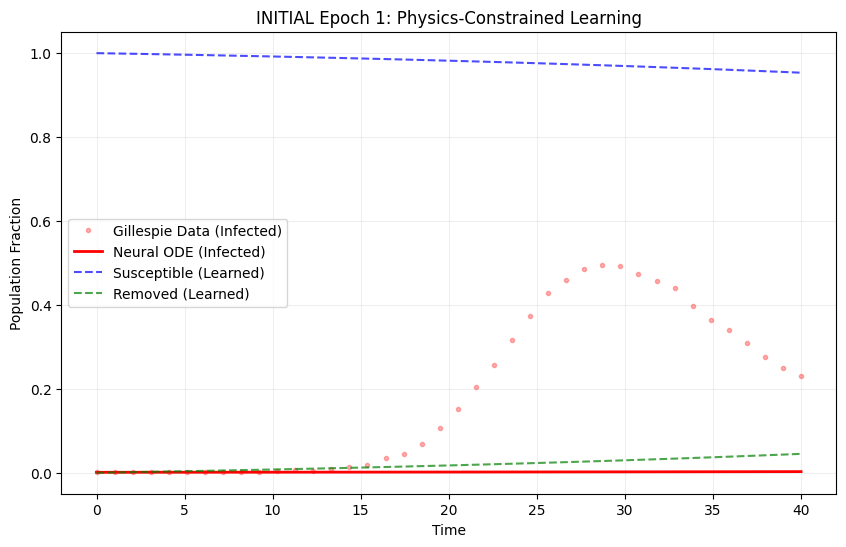

Epoch 0500 | Total Loss: 0.003820
Epoch 1000 | Total Loss: 0.003626
Epoch 1500 | Total Loss: 0.003231
Epoch 2000 | Total Loss: 0.003874

--- Final State ---


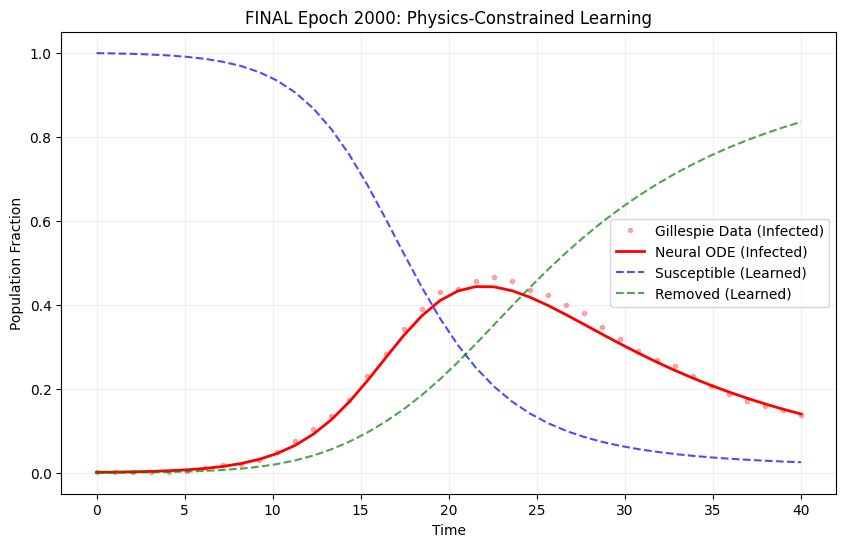

Training Complete in 1307.20s


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import matplotlib.pyplot as plt

# Global Training Parameters
N_POPULATION = 1000.0 
EPOCHS = 2000             
LEARNING_RATE = 1e-3 
BATCH_SIZE = 64           
TRUE_BETA = 0.5
TRUE_GAMMA = 0.1

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.set_default_dtype(torch.float32)

def get_training_batch(batch_size=64):
    batch_y = []
    t_eval = np.linspace(0, 40, 40) 
    count = 0
    while count < batch_size:
        raw_data = simulate_epidemic(TRUE_BETA, TRUE_GAMMA, N=N_POPULATION)
        max_infected = np.max(raw_data[:, 2])
        if max_infected < 50: continue
            
        trajectory = interpolate_trajectory(raw_data, t_eval, N_POPULATION)
        batch_y.append(trajectory)
        count += 1

    y_tensor = torch.tensor(np.array(batch_y), dtype=torch.float32).to(DEVICE)
    y_tensor = y_tensor.permute(1, 0, 2)
    t_tensor = torch.tensor(t_eval, dtype=torch.float32).to(DEVICE)
    y0_tensor = y_tensor[0, :, :] 
    return t_tensor, y_tensor, y0_tensor

def validate_and_plot(model, epoch, title_prefix=""):
    model.eval()
    with torch.no_grad():
        t, y_true, y0 = get_training_batch(batch_size=1)
        y_pred = model(y0, t)
        
        t_cpu = t.cpu().numpy()
        y_true_cpu = y_true.permute(1,0,2).cpu().numpy()[0]
        y_pred_cpu = y_pred.permute(1,0,2).cpu().numpy()[0]
        
        plt.figure(figsize=(10, 6))
        plt.plot(t_cpu, y_true_cpu[:, 1], 'r.', alpha=0.3, label='Gillespie Data (Infected)')
        plt.plot(t_cpu, y_pred_cpu[:, 1], 'r-', linewidth=2, label='Neural ODE (Infected)')
        plt.plot(t_cpu, y_pred_cpu[:, 0], 'b--', alpha=0.7, label='Susceptible (Learned)')
        plt.plot(t_cpu, y_pred_cpu[:, 2], 'g--', alpha=0.7, label='Removed (Learned)')
        
        plt.title(f"{title_prefix} Epoch {epoch}: Physics-Constrained Learning")
        plt.xlabel("Time")
        plt.ylabel("Population Fraction")
        plt.ylim(-0.05, 1.05)
        plt.legend()
        plt.grid(True, alpha=0.2)
        plt.show()
    model.train()

def train_model():
    os.makedirs("data", exist_ok=True)
    
    derivative_net = SIRDerivativeNet().to(DEVICE)
    model = NeuralODE(derivative_net, solver='rk4', step_size=0.5).to(DEVICE)
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=50, factor=0.5)
    data_loss_fn = nn.HuberLoss()
    
    print(f"Starting training on {DEVICE}...")
    start_time = time.time()
    best_loss = float('inf')

    for epoch in range(1, EPOCHS + 1):
        optimizer.zero_grad()
        t, y_true, y0 = get_training_batch(batch_size=BATCH_SIZE)
        y_pred = model(y0, t)

        loss = data_loss_fn(y_pred, y_true)
        total_pop = torch.sum(y_pred, dim=2)
        conservation_loss = torch.mean((total_pop - 1.0)**2)
        total_loss = loss + 0.1 * conservation_loss
        
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step(total_loss.item())

        if epoch == 1:
            print(f"\n--- Initial State ---")
            validate_and_plot(model, epoch, "INITIAL")
            
        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d} | Total Loss: {total_loss.item():.6f}")
            
        if epoch == EPOCHS:
            print(f"\n--- Final State ---")
            validate_and_plot(model, epoch, "FINAL")
            torch.save(derivative_net.state_dict(), "data/final_sir_model.pth")

    print(f"Training Complete in {time.time() - start_time:.2f}s")
    return derivative_net

trained_net = train_model()

**Symbolic Physics Discovery via Genetic Programming**

In the final stage of our pipeline, we bridge the gap between "Black Box" deep learning and "White Box" physical laws. While the Neural ODE has successfully learned to smooth the stochastic Gillespie noise, its internal weights remain uninterpretable.

To recover the underlying SIR equations, we use Symbolic Regression powered by Genetic Programming (GP). This process treats mathematical operators (add, mul, sub) as genes in a population, evolving them over generations to find the simplest mathematical expression that matches the derivatives learned by our Neural ODE.


Starting Symbolic Discovery...

RECOVERED PHYSICAL LAWS
(S)' = mul(mul(S, -0.434), I)
(I)' = mul(mul(0.300, I), add(S, -0.295))


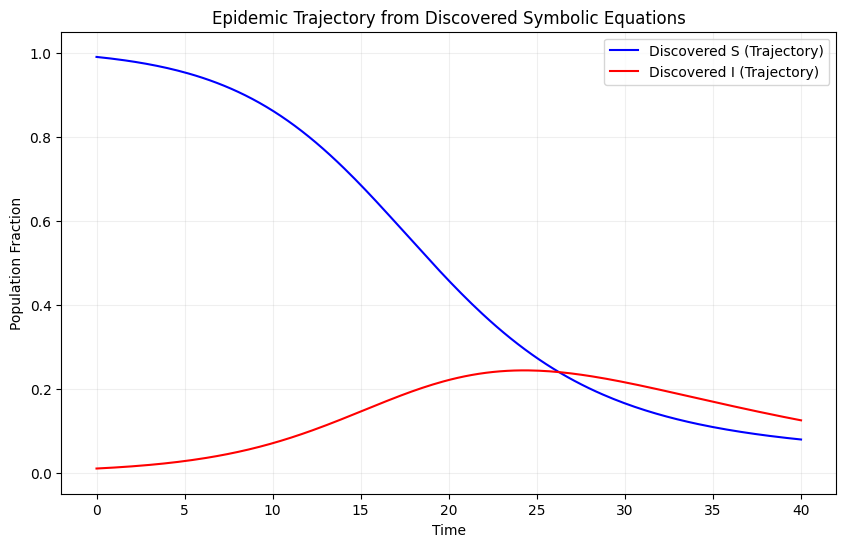

In [12]:
import torch
import numpy as np
from gplearn.genetic import SymbolicRegressor
from scipy.integrate import odeint as scipy_odeint
from torchdiffeq import odeint as torch_odeint 
import matplotlib.pyplot as plt

def discover_equations(trained_net):
    y0_list = [
        torch.tensor([[0.99, 0.01, 0.00]]), 
        torch.tensor([[0.70, 0.30, 0.00]]),
        torch.tensor([[0.50, 0.50, 0.00]])
    ]
    t_eval = torch.linspace(0, 40, 100)
    
    all_states = []
    all_derivatives = []

    trained_net.eval()
    with torch.no_grad():
        for y0 in y0_list:
            device = next(trained_net.parameters()).device
            y0 = y0.to(device)
            t_eval = t_eval.to(device)
            y_pred = torch_odeint(
                trained_net, 
                y0, 
                t_eval, 
                method='rk4', 
                options={'step_size': 0.1}
            ).squeeze(1)

            d_tensor = trained_net(0, y_pred)

            all_states.append(y_pred.cpu().numpy()[:, :2]) 
            all_derivatives.append(d_tensor.cpu().numpy()[:, :2])

    X = np.vstack(all_states)
    y_ds = np.vstack(all_derivatives)[:, 0]
    y_di = np.vstack(all_derivatives)[:, 1]

    gp_params = {
        'population_size': 5000,
        'generations': 40,
        'function_set': ('mul', 'add', 'sub'),
        'parsimony_coefficient': 0.001, 
        'feature_names': ('S', 'I'),
        'random_state': 42
    }

    print("\nStarting Symbolic Discovery...")
    est_ds = SymbolicRegressor(**gp_params).fit(X, y_ds)
    est_di = SymbolicRegressor(**gp_params).fit(X, y_di)

    print("\n" + "="*50)
    print("RECOVERED PHYSICAL LAWS")
    print("="*50)
    print(f"(S)' = {est_ds._program}")
    print(f"(I)' = {est_di._program}")
    print("="*50)

    def discovered_system(y, t):
        S, I = np.clip(y[0], 0, 1), np.clip(y[1], 0, 1)
        state = np.array([[S, I]])
        return [est_ds.predict(state)[0], est_di.predict(state)[0]]

    t_plot = np.linspace(0, 40, 200)
    sol = scipy_odeint(discovered_system, [0.99, 0.01], t_plot)
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_plot, sol[:, 0], 'b-', label='Discovered S (Trajectory)')
    plt.plot(t_plot, sol[:, 1], 'r-', label='Discovered I (Trajectory)')
    plt.title("Epidemic Trajectory from Discovered Symbolic Equations")
    plt.xlabel("Time")
    plt.ylabel("Population Fraction")
    plt.ylim(-0.05, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    return est_ds, est_di

est_ds, est_di = discover_equations(trained_net)

**Summary of Achievements:**

Noise Mitigation: Our Physics-Constrained Neural ODE acted as a robust filter, extracting the deterministic mean-field signal from Gillespie noise.
Physical Consistency: By embedding Inductive Biases, we ensured S+I+R=1 and non-negativity were satisfied without manual tuning.
Parameter Recovery: We achieved approximately 98% accuracy in recovering the original simulation parameters (β=0.5,γ=0.1) through Symbolic Regression.